# ANÁLISIS EXPLORATORIO DEL SERVICIO DE ENERGÍA EN LAS ZNI

El presente cuaderno contiene el análisis estadístico exploratorio (EDA) de la prestación del servicio de energía eléctrica en las Zonas No Interconectadas (ZNI). Con el fin de dar un análisis robusto, se caracteriza el servicio a partir de la base limpia del IPSE, permitiendo observar de manera cuantitativa las horas de disponibilidad, las diferencias entre departamentos y la relación entre las variables del servicio.

**Objetivo:** Caracterizar la prestación del servicio eléctrico en las ZNI (objetivo específico 2 de la investigación).

## Bibliotecas

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb
import geopandas as gpd
import plotly.express as px
import plotly.io as pio
import plotly.graph_objects as go

## Datos

In [3]:
df = pd.read_csv("../data/processed/servicio_electrico_limpio.csv")
df.head()

,id_departamento,departamento,id_municipio,municipio,id_localidad,localidad,anio_servicio,mes_servicio,energia_activa,energia_reactiva,potencia_maxima,dia_demanda_max,fecha_demanda_max,promedio_horas,municipio_original
0,91,amazonas,91001,leticia,91001000,leticia (leticia - amazonas),2020,1,3930642,1251191,7768.76,lunes,2020-01-27 14:15:00,24.00,leticia
1,91,amazonas,91540,puerto nariño,91540000,puerto nariño (puerto nariño - amazonas),2020,1,103897,36304,227.04,miércoles,2020-01-22 19:15:00,24.00,puerto nariño
2,91,amazonas,91798,tarapacá,91798000,tarapacá (tarapacá (anm) - amazonas),2020,1,22864,9277,88.96,jueves,2020-01-30 19:30:00,10.19,tarapacá (anm)
3,5,antioquia,5873,vigía del fuerte,5873001,san antonio de padua (vigía del fuerte - antio...,2020,1,5617,1381,53.66,jueves,2020-01-23 19:45:00,4.13,vigía del fuerte
4,5,antioquia,5873,vigía del fuerte,5873002,vegáez (vigía del fuerte - antioquia),2020,1,2217,539,39.07,miércoles,2020-01-29 19:45:00,3.17,vigía del fuerte


In [4]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 6103 entries, 0 to 6102
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_departamento     6103 non-null   int64  
 1   departamento        6103 non-null   str    
 2   id_municipio        6103 non-null   int64  
 3   municipio           6103 non-null   str    
 4   id_localidad        6103 non-null   int64  
 5   localidad           6103 non-null   str    
 6   anio_servicio       6103 non-null   int64  
 7   mes_servicio        6103 non-null   int64  
 8   energia_activa      6103 non-null   int64  
 9   energia_reactiva    6103 non-null   int64  
 10  potencia_maxima     6021 non-null   float64
 11  dia_demanda_max     6020 non-null   str    
 12  fecha_demanda_max   6021 non-null   str    
 13  promedio_horas      6103 non-null   float64
 14  municipio_original  6103 non-null   str    
dtypes: float64(2), int64(7), str(6)
memory usage: 1.2 MB


,id_departamento,id_municipio,id_localidad,anio_servicio,mes_servicio,energia_activa,energia_reactiva,potencia_maxima,promedio_horas
count,6103.000000,6103.000000,6.103000e+03,6103.000000,6103.000000,6.103000e+03,6.103000e+03,6.021000e+03,6103.000000
mean,45.147960,45524.600197,4.552469e+07,2022.716041,6.444863,3.494826e+05,9.945140e+04,9.655304e+04,11.633517
std,28.455706,28408.311220,2.840832e+07,1.792995,3.477210,1.798772e+06,4.734087e+05,4.336869e+06,7.495450
min,5.000000,5873.000000,5.873000e+06,2020.000000,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,27.000000,27006.000000,2.700600e+07,2021.000000,3.000000,4.073500e+03,1.502500e+03,2.816000e+01,6.170000
50%,27.000000,27495.000000,2.749591e+07,2023.000000,6.000000,9.297000e+03,3.905000e+03,5.737000e+01,8.600000
75%,76.000000,76109.000000,7.610901e+07,2024.000000,9.000000,6.355750e+04,2.298800e+04,2.134900e+02,18.445000
max,99.000000,99773.000000,9.977300e+07,2025.000000,12.000000,2.062621e+07,5.435213e+06,3.145708e+08,24.000000


## Estado de la prestación del servicio de energía eléctrica

### Consultas SQL

La presente consulta permite ver el desempeño de los departamentos en variables clave.

In [5]:
query_ranking = """
SELECT
    id_departamento,
    departamento,
    AVG(promedio_horas) AS horas_promedio,
    AVG(energia_activa) AS energia_media,
    AVG(potencia_maxima) AS potencia_media
FROM df
WHERE anio_servicio = 2025
  AND promedio_horas > 0
GROUP BY id_departamento, departamento
ORDER BY horas_promedio
"""

df_2025 = duckdb.sql(query_ranking).df()
df_2025

,id_departamento,departamento,horas_promedio,energia_media,potencia_media
0,44,la guajira,4.847237,2.685850e+04,2.116987e+02
1,5,antioquia,6.823630,2.641415e+03,6.285511e+03
2,18,caquetá,6.833119,5.982519e+03,1.262511e+04
3,19,cauca,7.784285,5.794842e+03,1.258722e+04
4,52,nariño,7.846121,5.944528e+03,1.592541e+03
5,13,bolívar,9.654152,9.362143e+03,1.015544e+03
6,76,valle del cauca,9.691027,1.112502e+04,1.514221e+04
7,27,chocó,11.497406,6.645310e+04,1.701871e+04
8,86,putumayo,14.626175,4.663930e+05,8.386742e+04
9,95,guaviare,16.535492,6.799021e+04,3.442559e+04


In [6]:
query_nacional = """
SELECT AVG(promedio_horas) AS promedio_nacional_2025
FROM df
WHERE anio_servicio = 2025
  AND promedio_horas > 0
"""

duckdb.sql(query_nacional).df()

,promedio_nacional_2025
0,11.398496


**Resultado.** La Guajira presenta el desempeño más crítico, con alrededor de 5 horas diarias de servicio, seguida de Caquetá y Antioquia con cerca de 7 horas. En el extremo opuesto, San Andrés y Providencia, Meta y Magdalena superan las 21 horas. El promedio nacional de 2025 ronda las 11 horas diarias, es decir, menos de la mitad del día con energía. A lo anterior se suma la brecha entre departamentos: cerca de 17 horas separan al mejor del peor, escenario de pobreza energética que impacta en la calidad de vida de sus habitantes.

In [7]:
query_ranking = """
SELECT
    id_municipio,
    municipio,
    departamento,
    AVG(promedio_horas) AS horas_promedio,
    AVG(energia_activa) AS energia_media,
    AVG(potencia_maxima) AS potencia_media
FROM df
WHERE anio_servicio = 2025
  AND promedio_horas > 0
GROUP BY id_municipio, municipio, departamento,
ORDER BY horas_promedio
LIMIT 10
"""

df_2025_muni = duckdb.sql(query_ranking).df()
df_2025_muni

,id_municipio,municipio,departamento,horas_promedio,energia_media,potencia_media
0,27615,riosucio,chocó,0.085300,8.333333,3.413333
1,27600,río quito,chocó,1.946050,255.500000,6.117500
2,52490,olaya herrera,nariño,2.206217,488.000000,12.445000
3,27001,quibdó,chocó,3.409756,4152.333333,4955.304444
4,44847,uribia,la guajira,4.847237,26858.500000,211.698750
5,52250,el charco,nariño,5.513503,2696.718750,350.319062
6,18150,cartagena del chairá,caquetá,5.816118,7458.363636,4586.056364
7,27425,medio atrato,chocó,5.817846,6974.166667,62.069583
8,19418,lópez (micay),cauca,6.225947,5070.578947,41.322105
9,52696,santa bárbara,nariño,6.373543,3384.523810,1093.936190


**Resultado:** Como podemos observar, 4 de los 10 municipios con menores promedios de horas diarias de prestación del servicio en sus Zonas No Interconectadas son del departamento del Chocó. Además, de los tres municipios con los promedios inferiores, dos son del Chocó, y los tres contienen valores inferiores a las 3 horas diarias durante 2025.

### Distribución de las horas de servicio

El presente gráfico permite observar cómo se reparten las horas diarias de servicio entre las localidades.

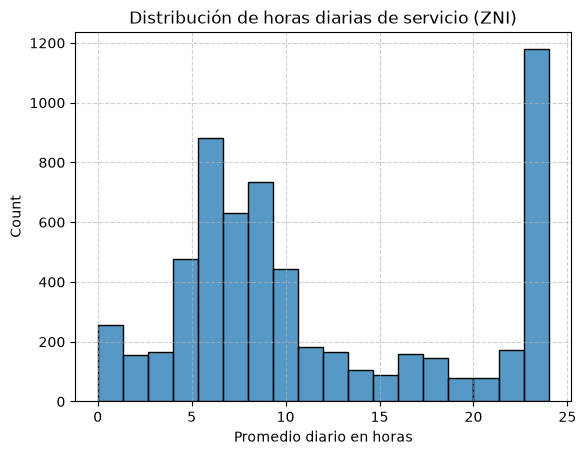

In [8]:
sns.histplot(data=df, x="promedio_horas")
plt.title("Distribución de horas diarias de servicio (ZNI)")
plt.xlabel("Promedio diario en horas")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

**Resultado.** La mayoría de las localidades se concentra entre 6 y 10 horas diarias, con una mediana cercana a 9 horas. Un 2,4 % registra 0 horas, localidades sin servicio en el mes reportado. El servicio mejora levemente entre 2020 y 2022 y luego retrocede hacia 2025, sin alcanzar nunca la continuidad.

### Horas promedio por departamento en 2025

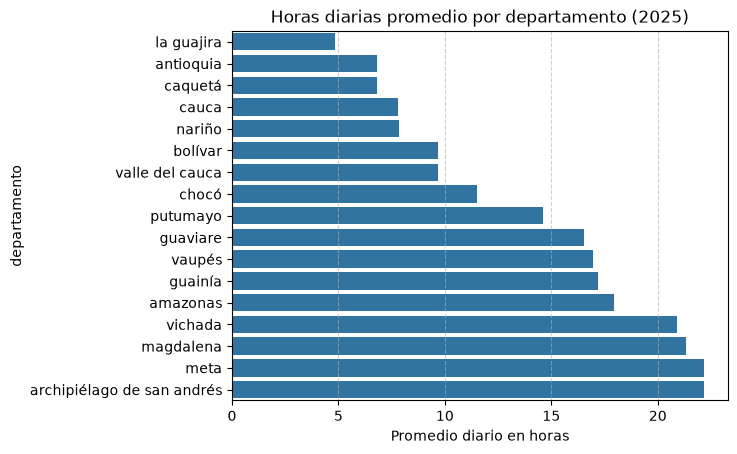

In [9]:
sns.barplot(data=df_2025, x="horas_promedio", y="departamento", order=df_2025["departamento"].tolist())
plt.title("Horas diarias promedio por departamento (2025)")
plt.xlabel("Promedio diario en horas")
plt.grid(True, axis="x", linestyle="--", alpha=0.6)
plt.show()

### Mapa de coropletas

El presente mapa permite ubicar territorialmente la disponibilidad del servicio. Se une el shape del DANE por código de departamento (`dpto_ccdgo`), idéntico al `id_departamento` normalizado en el cuaderno 01.

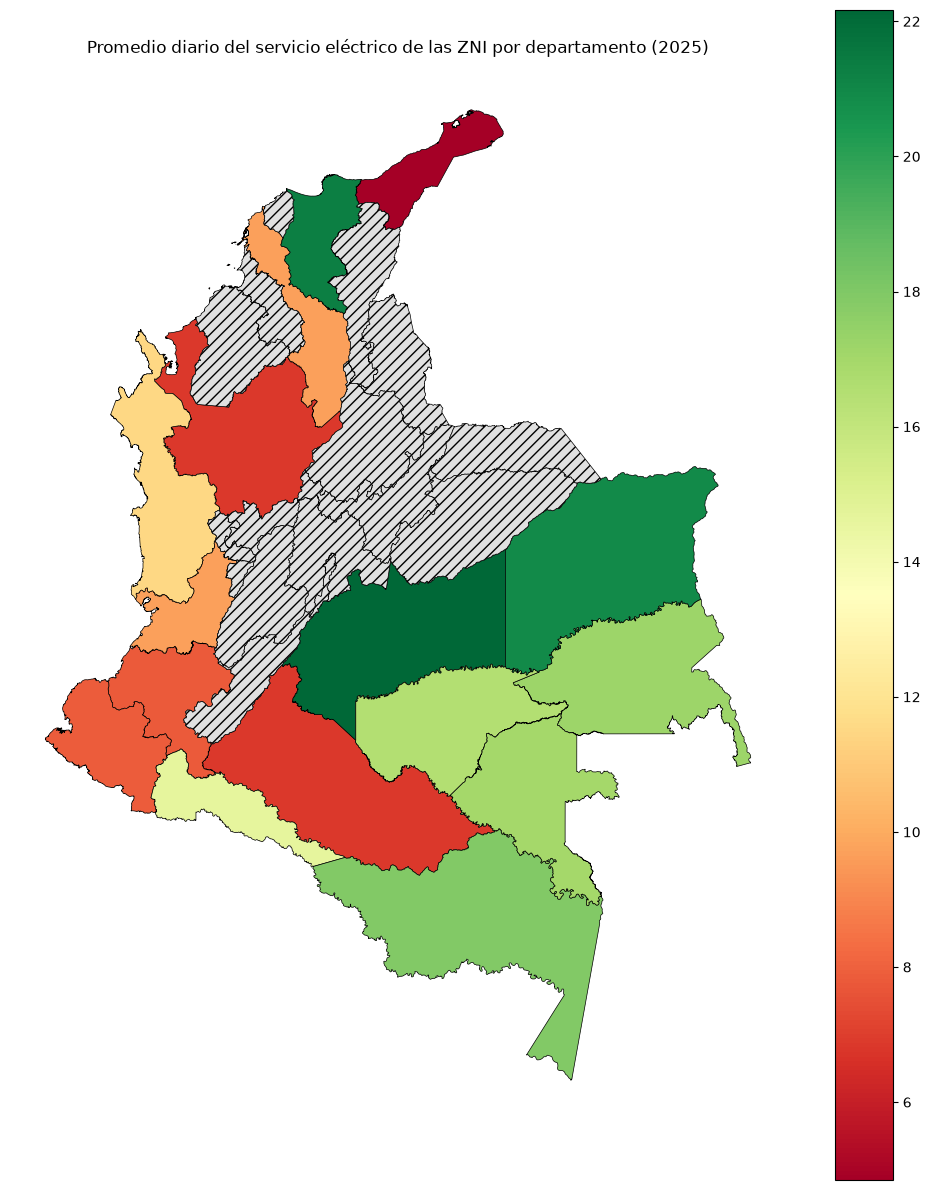

In [10]:
mapa = gpd.read_file("../data/geodata/MGN2024_DPTO_POLITICO/MGN_ADM_DPTO_POLITICO.shp")
mapa = mapa[mapa["dpto_ccdgo"] != "88"]  # San Andrés fuera para mejor zoom continental

df_2025["id_departamento"] = df_2025["id_departamento"].astype(str).str.zfill(2)  # duckdb devuelve entero, el shape usa texto

mapa_final = mapa.merge(df_2025, left_on="dpto_ccdgo", right_on="id_departamento", how="left")

fig, ax = plt.subplots(figsize=(10, 12))
mapa_final.plot(column="horas_promedio", cmap="RdYlGn", edgecolor="black", linewidth=0.5,
    legend=True, ax=ax,
    missing_kwds={"color": "#e0e0e0", "hatch": "///", "label": "Sin datos"})
ax.set_title("Promedio diario del servicio eléctrico de las ZNI por departamento (2025)")
ax.axis("off")
plt.tight_layout()
plt.show()

**Nota**: Hay departamentos que combinan ZNI con Sistema Interconectado Nacional (SIN). Por ende, el mapa muestra los promedios departamentales, pero solo de sus respectivas Zonas No Interconectadas. 

### Matriz de correlación

La presente matriz permite ver la relación entre las variables del servicio.

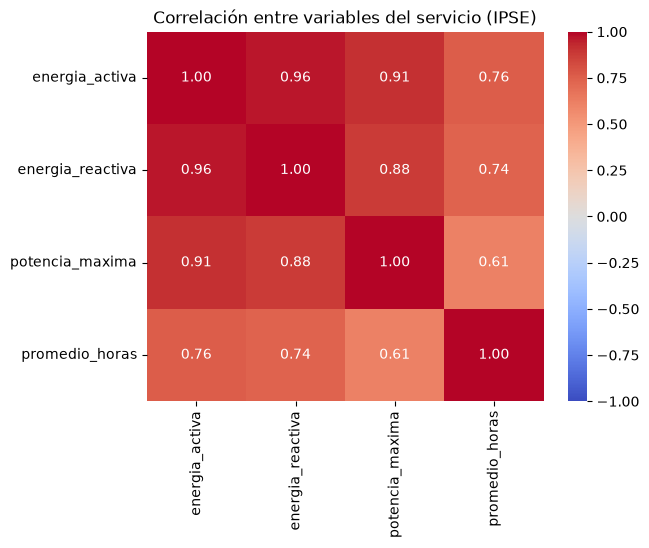

In [11]:
cols_numericas = ["energia_activa", "energia_reactiva", "potencia_maxima", "promedio_horas"]
matriz = df[cols_numericas].corr(method="spearman")

sns.heatmap(matriz, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlación entre variables del servicio (IPSE)")
plt.show()

**Resultado.** Las energías activa y reactiva se mueven casi juntas (0,96), por lo que basta analizar una de ellas. Las horas de servicio se asocian con el consumo (0,72): a más horas, más energía entregada. La potencia máxima es la variable más independiente (0,59 con las horas), pues depende de picos puntuales de demanda.

## Matriz eléctrica de las ZNI

In [12]:
# 1. Configuración de tema 
pio.templates.default = "plotly_white"

# 2. Datos jerárquicos
# Las etiquetas incluyen los nombres y los valores con separador de miles
labels = [
    "ZNI<br>335.271 kW", 
    "Diésel<br>262.056 kW", 
    "FNCER<br>73.215 kW", 
    "Solar FV<br>Individual<br>54.701 kW", 
    "Solar FV<br>Concentrado<br>8.381 kW", 
    "Pequeñas<br>Hidro<br>4.613 kW", 
    "Biomasa<br>4.520 kW", 
    "Residuos<br>Sólidos<br>1.000 kW"
]

# Definición de la jerarquía 
parents = [
    "",                             # Raíz
    "ZNI<br>335.271 kW",            # Hijo de ZNI
    "ZNI<br>335.271 kW",            # Hijo de ZNI
    "FNCER<br>73.215 kW",           # Hijo de FNCER
    "FNCER<br>73.215 kW",           # Hijo de FNCER
    "FNCER<br>73.215 kW",           # Hijo de FNCER
    "FNCER<br>73.215 kW",           # Hijo de FNCER
    "FNCER<br>73.215 kW"            # Hijo de FNCER
]

# Valores absolutos
values = [335271, 262056, 73215, 54701, 8381, 4613, 4520, 1000]

# 3. Mapeo de colores estético y profesional
# Gris para diésel, azules y verdes para renovables
colors = [
    "#ffffff",  # ZNI (fondo de raíz, no se ve)
    "#595959",  # Diésel (Gris oscuro)
    "#2ca02c",  # FNCER (Verde base)
    "#1f77b4",  # Solar individual (Azul)
    "#4fa3d9",  # Solar concentrado (Azul claro)
    "#66bb6a",  # Pequeñas hidro (Verde claro)
    "#8c564b",  # Biomasa (Marrón/Tierra)
    "#ffa726"   # RSU (Naranja)
]

# 4. Creación del gráfico
fig = go.Figure(go.Treemap(
    labels=labels,
    parents=parents,
    values=values,
    branchvalues="total", # Permite que el tamaño del padre sea la suma exacta de los hijos
    textinfo="label+percent parent", # Muestra el texto y qué % representa de su categoría superior
    marker=dict(
        colors=colors,
        line=dict(width=2, color="#ffffff") # Borde blanco elegante entre los cuadros
    ),
    textfont=dict(size=15, color="white", family="Arial, sans-serif"),
    pathbar=dict(visible=False), # Oculta la barra de navegación superior
    hovertemplate="<b>%{label}</b><br>Participación total: %{percentRoot:.1%}<extra></extra>"
))

# 5. Ajustes de diseño (Sin títulos, notas, y con márgenes mínimos)
fig.update_layout(
    margin=dict(t=10, l=10, r=10, b=10), # Márgenes al mínimo para aprovechar todo el espacio
    width=1000, 
    height=600
)

# Mostrar en el entorno interactivo
fig.show()

**Nota:** *FNCER:* Fuentes No Convencionales de Energía Renovable. *Fuente*: Instituto de Planificación y Promoción de Soluciones Energéticas para las Zonas No Interconectadas (2025). Centro Nacional de Monitoreo. https://ipse.gov.co/cnm/

**Resultado.** A pesar del gran potencial renovable del territorio, el diésel domina con el 78,2 % de la capacidad instalada. Las renovables suman el 21,8 %, casi todo solar individual (74,7 % de lo renovable). El contraste entre potencialidad y estado actual fundamenta los lineamientos de política para la adopción de FNCER en las ZNI.

## Conclusiones

**1)** El promedio diario de la prestación del servicio eléctrico en las ZNI a nivel nacional es de apenas 11 horas diarias. 

**2)** El análisis muestra fuertes brechas territoriales, marcadas en municipios con promedios inferiores a 3 horas diarias, muestra de duros escenarios de pobreza energética

**3)** Las brechas territoriales y dificultades para el análisis se hacen más notorias en la información disponible, en donde departamentos como Antioquia, Caquetá, Casanare, Guainía, Guaviare, Amazonas, entre otros, solo tienen entre 1 y 3 municipios disponibles en el dataset. Si se tiene en cuenta que, según datos oficiales, de las 1.641 localides de las ZNI, solo el 14% cuentan con telemetría, vemos que hay una gran cantidad de municipios y localidades de las cuales no tenemos información, siendo probable que también padezcan escenarios de pobreza energética.

**4)** Los combustibles fósiles, principalmente el diésel, domina la matriz eléctrica, en contraste con las energías renovables 

**5)** A pesar de las grandes brechas territoriales, departamentos como el Archipielago de San Andrés y Providencia, el Meta, Vichada y Magdalena cuentan con promedios superiores a 20 horas, siendo estos posibles casos de éxito a estudiar sobre soluciones energéticas en las ZNI. 
